In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# We assume that the project folder is located in the home directory
home_dir = os.path.expanduser("~")
sys.path.insert(0, os.path.abspath(os.path.join(home_dir, 'DSAIT4030-group12')))

from diffuser.diffuser_ddpm_linear_schedule import Diffuser_DDPM_linear_schedule 
from diffuser.unet import DiffusionUNet

from dataset_loader import load_dataset
from torch.utils.data import DataLoader
from vae.vae import VAE

# Config:
from diffuser.unet_config import DiffuserConfig

/home/remcohuijsen/anaconda3/envs/diffusion_fresh/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup

In [2]:
#Init
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_string = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

torch.manual_seed(0)
np.random.seed(0)

cuda


In [3]:
# Create scheduler model
ddpm_model = Diffuser_DDPM_linear_schedule(total_timesteps=1000, beta_start=0.0001, beta_end=0.02)

ddpm_model.betas = ddpm_model.betas.to(device)
ddpm_model.alphas = ddpm_model.alphas.to(device)
ddpm_model.alpha_bars = ddpm_model.alpha_bars.to(device)

In [4]:
# Create model
config = DiffuserConfig()
unet = DiffusionUNet(
    config=config,
    model_in_channels=4,
    model_out_channels=4
).to(device)

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4, weight_decay=1e-6)


In [5]:
# Load VAE
vae = VAE(mode="kl").to(device)
checkpoint = torch.load("../step_100000.pt", map_location=device, weights_only=False)

vae.load_state_dict(checkpoint["vae"], strict=False)

<All keys matched successfully>

In [6]:
# Checkpointing: load existing checkpoint if available and helper to save checkpoints
checkpoint_dir = os.path.abspath(os.path.join('..', 'checkpoints'))
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_last = os.path.join(checkpoint_dir, 'checkpoint_last.pt')
save_every = 400  # steps - set to 0 to disable periodic saving

start_step = 0
# Attempt to resume from the last checkpoint if present
if os.path.exists(checkpoint_last):
    print(f'Loading resume checkpoint: {checkpoint_last}')
    ck = torch.load(checkpoint_last, map_location=device)
    if 'unet_state' in ck:
        try:
            unet.load_state_dict(ck['unet_state'])
            print('Loaded UNet weights from checkpoint')
        except Exception as e:
            print('Warning: could not strictly load UNet weights:', e)
    if 'optimizer_state' in ck:
        try:
            optimizer.load_state_dict(ck['optimizer_state'])
            print('Restored optimizer state')
        except Exception as e:
            print('Warning: could not restore optimizer state:', e)
    # ddpm model state if available
    if 'ddpm_state' in ck and hasattr(ddpm_model, 'load_state_dict'):
        try:
            ddpm_model.load_state_dict(ck['ddpm_state'])
            print('Restored DDPM scheduler state')
        except Exception as e:
            print('Warning: could not restore DDPM state:', e)
    start_step = int(ck.get('step', 0)) + 1
    print(f'Resuming from step {start_step}')
else:
    print('No resume checkpoint found, starting from scratch')

def save_checkpoint(step):
    ck = {
        'step': int(step),
        'unet_state': unet.state_dict(),
        'optimizer_state': optimizer.state_dict(),
    }
    if hasattr(ddpm_model, 'state_dict'):
        try:
            ck['ddpm_state'] = ddpm_model.state_dict()
        except Exception:
            pass
    torch.save(ck, os.path.join(checkpoint_dir, f'ckpt_step_{step}.pt'))
    torch.save(ck, checkpoint_last)
    print(f'Saved checkpoint for step {step} ->', os.path.join(checkpoint_dir, f'ckpt_step_{step}.pt'))

No resume checkpoint found, starting from scratch


In [7]:
# Loads data and uses VAE to generate latents
def load_data(NUM_WORKERS, BATCH_SIZE, DATASET):
    train_set = load_dataset(DATASET, split="train")

    train_loader = DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
        persistent_workers=True if NUM_WORKERS > 0 else False,
    )

    return train_loader

In [8]:
def train_step(data_iter, batch_size, model, ddpm):
    
    model.train()
    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    data_samples = 0

    for batch in data_iter:
        data_minibatch = batch["images"].to(device, non_blocking=True)
        
        with torch.no_grad():
            data_minibatch = vae.encode(data_minibatch) * 0.18215

        # Randomly sample diffusion timesteps for each data sample in the minibatch.
        B = data_minibatch.shape[0]
        t = torch.randint(0, ddpm.total_timesteps, (B,), device=device, dtype=torch.long).view(-1)

        # Perform a forward diffusion step to time t and retrieve the corresponding noisy sample x_t and the true added noise.
        x_t, true_noise = ddpm.forward_diffusion(data_minibatch, t)
        
        # Let the prediction model predict the added noise given the noisy sample x_t and the diffusion timestep t.
        pred_noise = model(x_t, t)
        
        # Compute loss and backprop (normalized by total batch for stability)
        loss = F.mse_loss(pred_noise, true_noise)
        loss.backward()

        total_loss += loss.detach().item() * B
        data_samples += B

        # Step when we've accumulated enough samples
        if data_samples >= batch_size:
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            break

    return total_loss / max(data_samples, 1)


# Sampling

In [9]:
@torch.no_grad()
def sample(model, ddpm, shape, fixed_noise=None):
    model.eval()

    x = torch.randn(shape, device=device)

    if fixed_noise != None:
        x = fixed_noise

    for t in range(ddpm.total_timesteps - 1, 0, -1):
        ts = torch.full((shape[0],), t, device=device, dtype=torch.long).view(-1)
        pred_noise = model(x, ts)
        x = ddpm.reverse_diffusion(x, ts, pred_noise)

    return x

In [10]:
def show_images(img_batch, title=None):
    img_batch = img_batch.detach().cpu()
    fig, axes = plt.subplots(1, img_batch.shape[0], figsize=(4 * img_batch.shape[0], 4))
    if img_batch.shape[0] == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        img = img_batch[i]
        img = (img + 1.0) / 2.0
        img = (img * 255.0).clamp(0, 255).byte()
        img = img.permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis("off")

    if title:
        fig.suptitle(title)
    plt.show()

# Run and Show

/home/remcohuijsen
step     0 | loss 1.1108


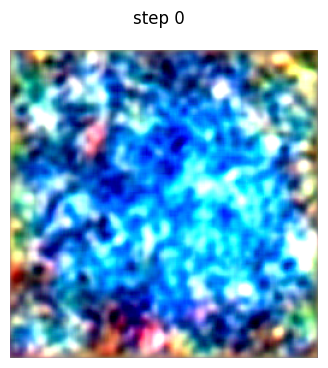

/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step    25 | loss 1.5390
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step    50 | loss 0.5484


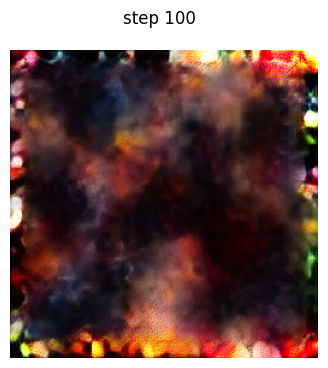

/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step   125 | loss 0.0909
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step   150 | loss 0.0956


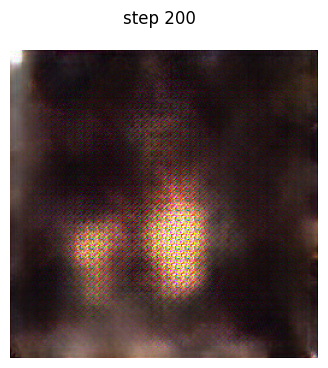

/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step   225 | loss 0.0844
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step   250 | loss 0.1383


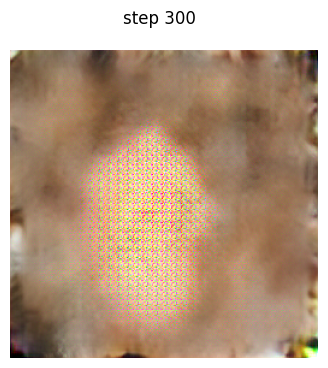

/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step   325 | loss 0.0803
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step   350 | loss 0.0935


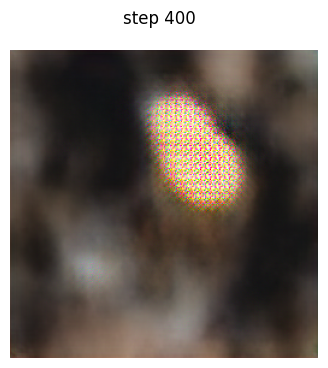

Saved checkpoint for step 400 -> /home/remcohuijsen/DSAIT4030-group12/checkpoints/ckpt_step_400.pt
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step   425 | loss 0.0667
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/h

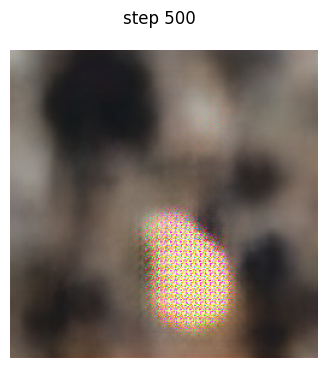

/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step   525 | loss 0.0541
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step   550 | loss 0.0632


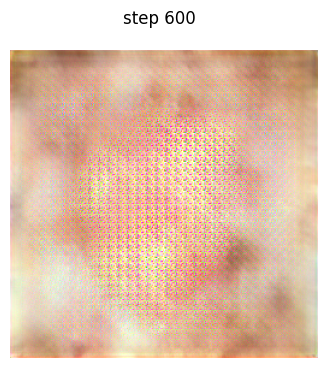

/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step   625 | loss 0.0603
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
/home/remcohuijsen
step   650 | loss 0.0920


In [ ]:
# training loop:
num_steps = 10000
batch_size = 256
minibatch_size = 16
num_workers = 0

print_loss_every = 25
preview_every = 100

# Use start_step from checkpoint (if resumed) otherwise 0
for i in range(start_step, num_steps):
    train_loader = load_data(num_workers, minibatch_size, "celeba")
    data_i = iter(train_loader)
    
    with torch.amp.autocast(device_type=device_string, dtype=torch.bfloat16):
    
        loss = train_step(data_i, batch_size, unet, ddpm_model)

    if i % print_loss_every == 0:
        print(f"step {i:5d} | loss {loss:.4f}")

    if i % preview_every == 0:
        unet.eval()
        with torch.no_grad():
            latent_samples = sample(unet, ddpm_model, (1, 4, 32, 32))
            samples = vae.decode(latent_samples)
        show_images(samples, title=f"step {i}")
        unet.train()

    # periodic checkpoint save
    if save_every and save_every > 0 and (i % save_every == 0) and i != start_step:
        save_checkpoint(i)


In [ ]:
show_images(samples, title="Generated samples")

In [ ]:
with torch.no_grad():
    samples = vae.decode(sample(unet, ddpm_model, (1, 4, 32, 32)))
